# Portfolio VaR & Risk Model

## 1. Data & Portfolio Setup

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm, chi2

np.random.seed(42) # Fixed seed used to make Monte Carlo results results reproducable
pf_value = 1_000_000

In [2]:
tickers = ['SPY', 'QQQ', 'TLT', 'GLD', 'IWM']
data = yf.download(tickers, start="2021-01-01", end="2026-01-01", auto_adjust=True)
prices = data['Close']
weights = np.array([.40, .25, .15, .10, .10])
if not np.isclose(weights.sum(), 1):
    raise ValueError("Portfolio weights must sum to 1.")

portfolio = pd.DataFrame({
    "Ticker": tickers,
    "Weights": weights
})

[*********************100%***********************]  5 of 5 completed


In [3]:
returns = prices.pct_change()
returns = returns[tickers]
returns = returns.dropna()
pf_returns = returns.dot(weights)

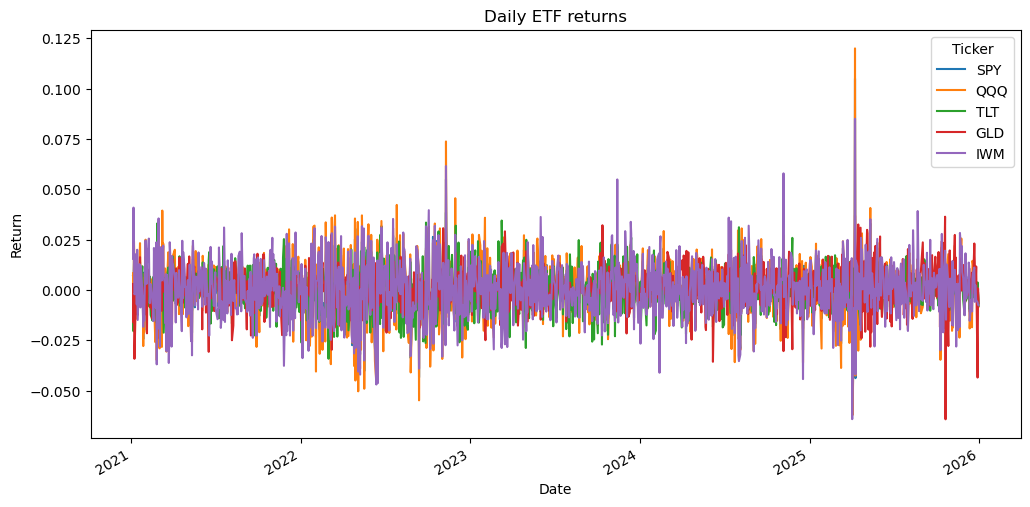

In [4]:
returns.plot(figsize=(12,6))
plt.ylabel('Return')
plt.xlabel('Date')
plt.title('Daily ETF returns')
plt.show()

Text(0.5, 1.0, 'Asset Return Correlation Matrix')

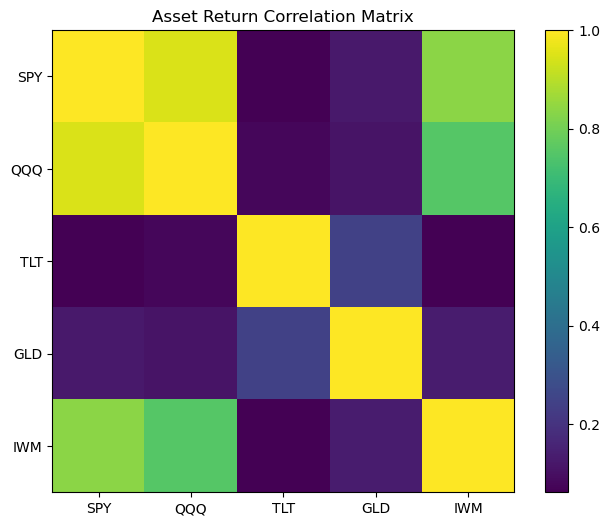

In [5]:
cov_matrix = returns.cov()
corr_matrix = returns.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Asset Return Correlation Matrix")

In [6]:
def calculate_pf_vol(returns, weights):
    cov_matrix = returns.cov()
    pf_variance = weights.T @ cov_matrix.values @ weights
    pf_daily_vol = np.sqrt(pf_variance)
    pf_annual_vol = pf_daily_vol * np.sqrt(252) # sqrt(252) accounts for 252 trading days in a year to annualize vol
    return pf_annual_vol

In [7]:
pf_vol = calculate_pf_vol(returns, weights)
individual_vol = returns.std() * np.sqrt(252)
weighted_avg_vol = (individual_vol * weights).sum()
print(
    f"Weighted Average Volatility: "
    f"{weighted_avg_vol:.2%}"
)

print(
    f"Portfolio Volatility: "
    f"{pf_vol:.2%}"
)

Weighted Average Volatility: 18.78%
Portfolio Volatility: 14.97%


These statistics provide a base view of the volatility characteristics of the portfolio, giving us a foundation for the more detailed analyses that 
follow (VaR, Expected Shortfall, Stress Testing, Risk Decomposition).                                                                                 

## 2. Return Distribution, VaR & Expected Shortfall


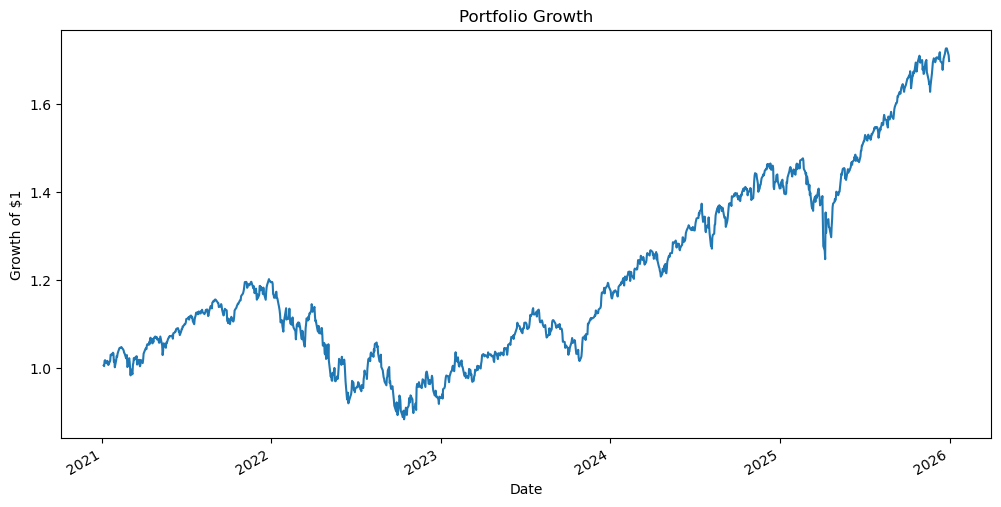

In [8]:
cum_returns = (1+pf_returns).cumprod()
cum_returns.plot(figsize=(12,6))
plt.title("Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

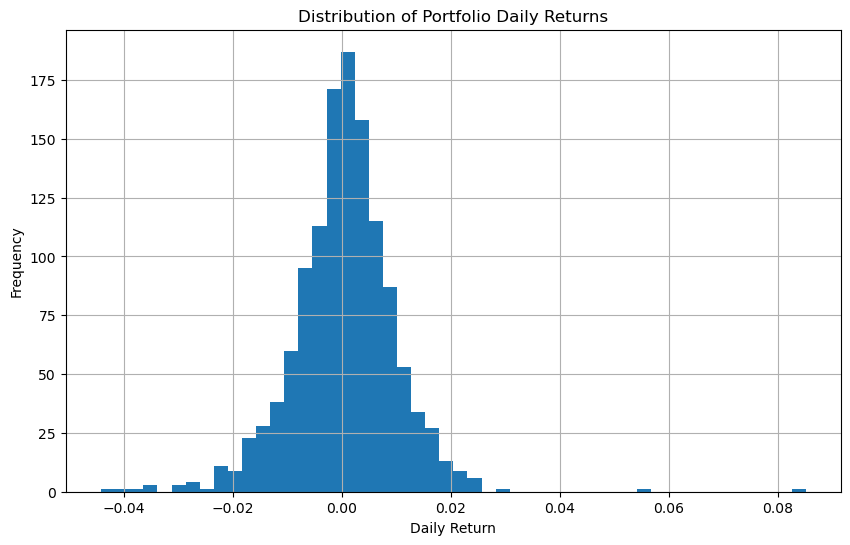

In [9]:
pf_returns.hist(bins=50, figsize=(10,6))
plt.title("Distribution of Portfolio Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [10]:
def hist_var(pf_returns, confidence_level, pf_value):
    var_return = np.percentile(pf_returns, (1 - confidence_level) * 100)
    var_dollars = -1 * var_return * pf_value
    return var_dollars

In [11]:
def parametric_var(pf_returns, confidence_level, pf_value):
    mean = pf_returns.mean()
    vol = pf_returns.std()
    z = norm.ppf(1 - confidence_level)
    var = -(mean + vol * z) * pf_value
    return var

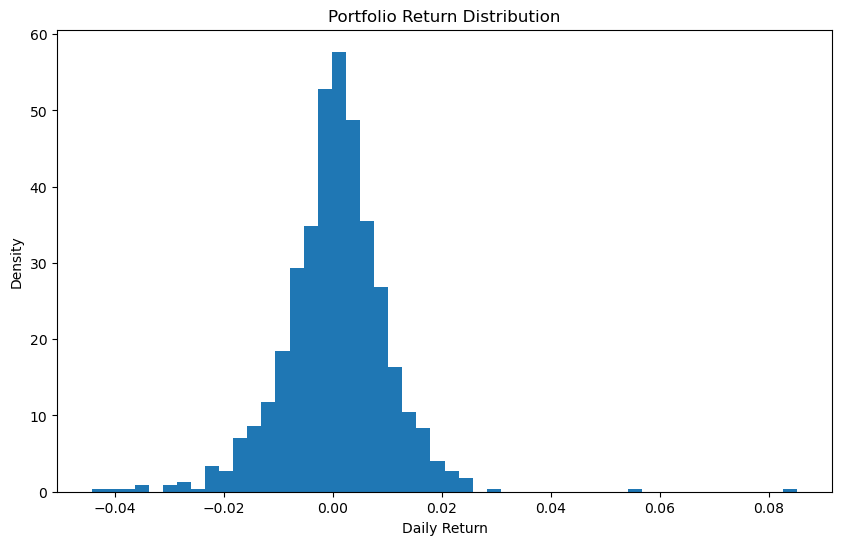

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    pf_returns,
    bins=50,
    density=True
)

plt.title("Portfolio Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.show()

In [13]:
def calculate_var(pf_returns, confidence_level, pf_value, method):
    if method.lower() == "parametric":
        var = parametric_var(pf_returns, confidence_level, pf_value)
    elif method.lower() == "historical":
        var = hist_var(pf_returns, confidence_level, pf_value)
    else:
        raise ValueError('invalid method')
    return var

In [14]:
def hist_es(pf_returns, confidence_level, pf_value):
    var_thresh = np.percentile(pf_returns, (1 - confidence_level) * 100)
    tail_returns = pf_returns[pf_returns <= var_thresh]
    avg_tail_return = tail_returns.mean()
    es = -(avg_tail_return)
    es_dollars = es * pf_value
    return es_dollars

hist_es(pf_returns, .95, pf_value)

np.float64(21442.06258429461)

In [15]:
def var_engine(pf_returns, confidence_levels, pf_value): # Runs Historical VaR, Parametric VaR, and Expected Shortfall
    results = []
    for confidence in confidence_levels:
        hist = calculate_var(pf_returns, confidence, pf_value, 'historical')
        parametric = calculate_var(pf_returns, confidence, pf_value, 'parametric')
        var_diff = parametric - hist
        var_pct_diff = var_diff / hist
        es = hist_es(pf_returns, confidence, pf_value)
        results.append({"Confidence": confidence, "Historical VaR": hist, "Parametric VaR": parametric, "Parametric - Historical VaR": var_diff, "Parametric - Historical VaR Percentage Difference": var_pct_diff, "Expected Shortfall": es})
    var_results = pd.DataFrame(results)
    return var_results
  
var_results = var_engine(
    pf_returns,
    [0.90, 0.95, 0.99],
    pf_value
)

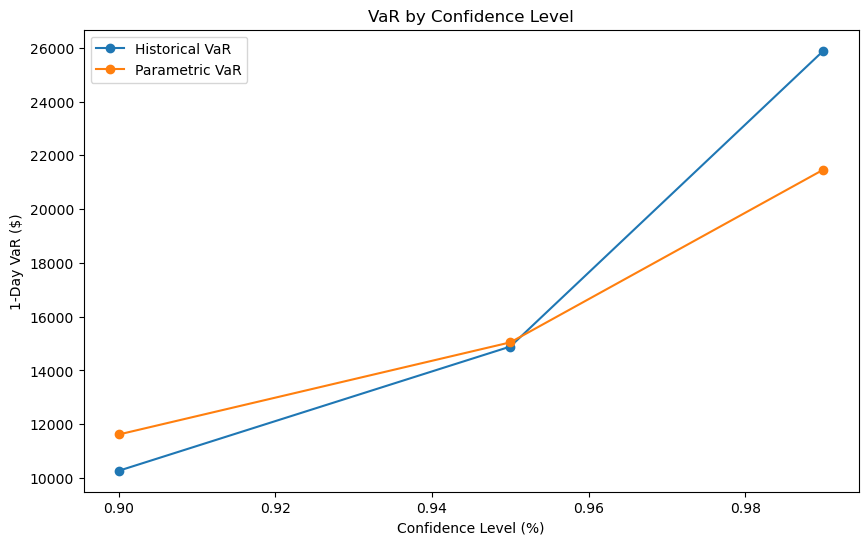

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    var_results["Confidence"],
    var_results["Historical VaR"],
    marker="o",
    label="Historical VaR"
)

plt.plot(
    var_results["Confidence"],
    var_results["Parametric VaR"],
    marker="o",
    label="Parametric VaR"
)

plt.title("VaR by Confidence Level")
plt.xlabel("Confidence Level (%)")
plt.ylabel("1-Day VaR ($)")
plt.legend()

plt.show()

Historical and Parametric VaR provide relatively similar results at the 90% and 95% confidence levels, but their difference becomes more significant at the 99% confidence level. Historical VaR exceeding parametric VaR at the 99% confidence level suggests that the parametric VaR's assumption of normally distributed returns may understate the portfolio's tail losses.

In [17]:
confidence_levels = [0.9, 0.95, 0.99]
results = []
for cl in confidence_levels:
    var = calculate_var(pf_returns, cl, pf_value, 'historical')
    es = hist_es(pf_returns, cl, pf_value)
    diff = es - var
    pct_diff = diff / var
    results.append({'Confidence Level': f'{cl:.0%}', 'VaR':var, 'ES': es, 'Difference': diff, 'Percentage Difference': pct_diff})
es_vs_var = pd.DataFrame(results)
print(es_vs_var)

  Confidence Level           VaR            ES   Difference  \
0              90%  10269.084620  16914.238650  6645.154030   
1              95%  14887.246181  21442.062584  6554.816403   
2              99%  25893.462120  32546.533649  6653.071529   

   Percentage Difference  
0               0.647103  
1               0.440297  
2               0.256940  


Expected Shortfall significantly exceeds VaR at all confidence levels, demonstrating the importance of analyzing the severity of tail losses rather than simply relying on a VaR Threshold.

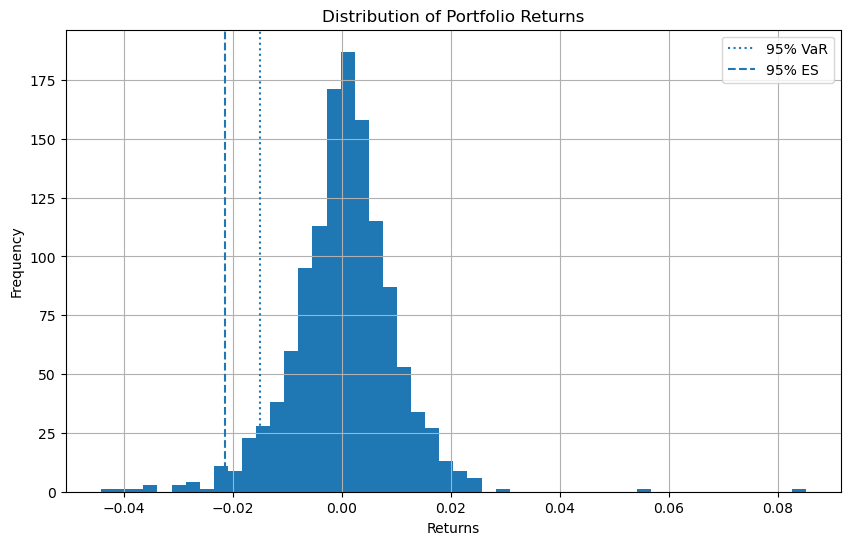

In [18]:

var_95 = -(calculate_var(pf_returns, 0.95, 1, 'historical')) # pf_value= 1  keeps VaR/ES as fractions, so that they end up on the same x-axis as the return histogram.
es_95 = -(hist_es(pf_returns, 0.95, 1))
pf_returns.hist(figsize=(10,6), bins = 50)
plt.title('Distribution of Portfolio Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(var_95, linestyle='dotted', label='95% VaR')
plt.axvline(es_95, linestyle='dashed', label='95% ES')
plt.legend()

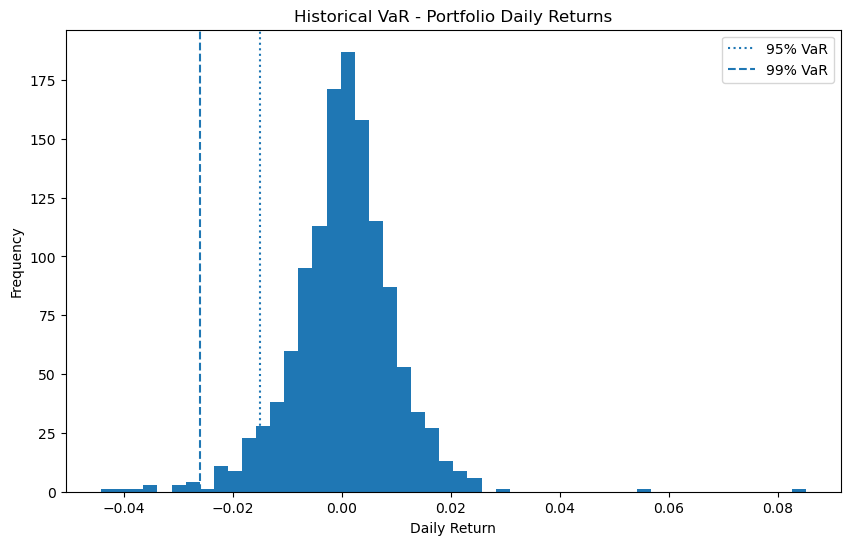

In [19]:
var_95_return = np.percentile(pf_returns, 5)
var_99_return = -(calculate_var(pf_returns, .99, 1, 'historical'))
plt.figure(figsize=(10,6))
plt.hist(pf_returns, bins=50)
plt.axvline(var_95_return, linestyle='dotted', label = '95% VaR')
plt.axvline(var_99_return, linestyle='dashed', label = '99% VaR')
plt.title('Historical VaR - Portfolio Daily Returns')
plt.xlabel("Daily Return")
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 3. VaR Calibration Check

In [20]:
def calibration_check(pf_returns, confidence_levels): #unconditional coverage comparing observed vs expected breach rate
    results = []
    for cl in confidence_levels:
        var_thresh = np.percentile(pf_returns, (1-cl)*100)
        breaches = pf_returns < var_thresh
        num_breaches = breaches.sum()
        breach_rate = breaches.mean()
        exp_breach_rate = 1 - cl
        breach_diff = exp_breach_rate - breach_rate
        results.append({'Confidence Level': cl, "VaR Threshold": var_thresh, 'Breaches': num_breaches, "Breach Rate": breach_rate, "Expected Breach Rate": exp_breach_rate, "Rate Difference": breach_diff}) 
    data = pd.DataFrame(results)
    return data

calibration_check(pf_returns, confidence_levels)

,Confidence Level,VaR Threshold,Breaches,Breach Rate,Expected Breach Rate,Rate Difference
0,0.90,-0.010269,126,0.100478,0.10,-0.000478
1,0.95,-0.014887,63,0.050239,0.05,-0.000239
2,0.99,-0.025893,13,0.010367,0.01,-0.000367


In [21]:
def kupiec_test(pf_returns, confidence_level):
    """Kupiec Proportion-of-Failures test:
    H0: observed breach rate = expected breach rate. 
    H1: observed breach rate != expected breach rate."""
    var_thresh = np.percentile(pf_returns, (1 - confidence_level) * 100)
    breaches = pf_returns < var_thresh
    num_breaches = breaches.sum()
    total_observations = breaches.count()
    observed_rate = breaches.mean()
    exp_rate = 1 - confidence_level
    lr_pof = -2* np.log(((1 - exp_rate)**(total_observations - num_breaches) * exp_rate ** num_breaches) 
                       / ((1 - observed_rate) ** (total_observations - num_breaches) * observed_rate ** num_breaches))
    p_value = 1 - chi2.cdf(lr_pof, 1)
    return lr_pof, p_value


lr_pof, p_value_pof = kupiec_test(pf_returns, 0.95)

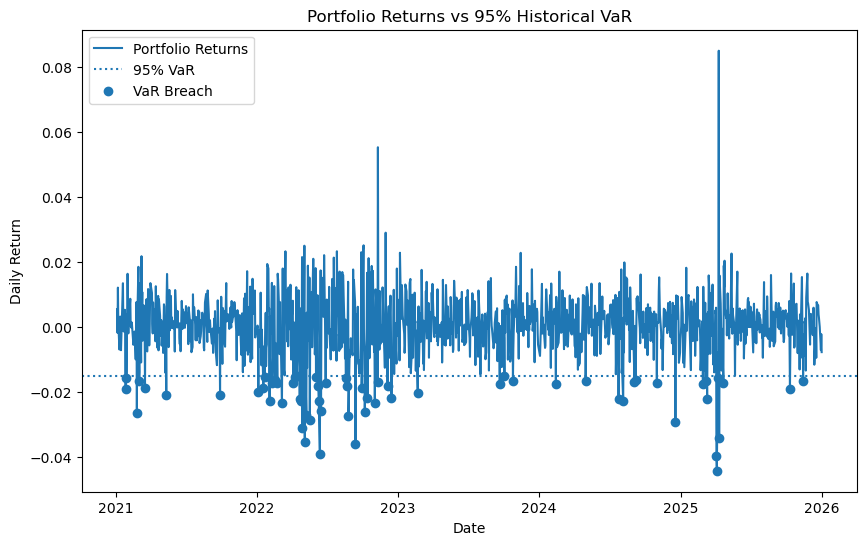

In [22]:
var_95_returns = np.percentile(pf_returns, (1 - 0.95) * 100)
breaches = pf_returns < var_95_returns
num_breaches = breaches.sum()
breach_rate = breaches.mean()

plt.figure(figsize=(10,6))
plt.plot(pf_returns, label='Portfolio Returns')
plt.axhline(var_95_returns, linestyle='dotted', label='95% VaR')
plt.scatter(pf_returns.index[breaches], pf_returns[breaches], label='VaR Breach')
plt.title("Portfolio Returns vs 95% Historical VaR")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

In [23]:
confidence_level = 0.95
def ind_test(pf_returns, confidence_level):
    """Christoffersen independence test:
    H0: breaches are independent over time.
    H1: breaches are dependent over time."""
    var_thresh = np.percentile(pf_returns, (1 - confidence_level) * 100)
    breach = pf_returns < var_thresh
    prev_breach = breach.shift(1) #makes the first observation NaN so the first day is excluded
    n00 = ((prev_breach == False) & (breach == False)).sum()
    n01 = ((prev_breach == False) & (breach == True)).sum()
    n10 = ((prev_breach == True) & (breach == False)).sum()
    n11 = ((prev_breach == True) & (breach == True)).sum()
    pi01 = n01 / (n01 + n00)
    pi11 = n11 / (n11 + n10)
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    lr_ind = -2 * np.log(
        (
            (1 - pi)**(n00 + n10)
            * pi**(n01 + n11)
        )
        /
        (
            (1 - pi01)**n00
            * pi01**n01
            * (1 - pi11)**n10
            * pi11**n11
        )
    )
    return {'n00': n00, 'n01': n01, 'n10': n10, 'n11': n11, 'pi01': pi01, 'pi11': pi11, 'pi': pi, 'lr_ind': lr_ind}
ind_results = ind_test(pf_returns, confidence_level)
lr_ind = ind_results['lr_ind']
p_value_ind = chi2.sf(lr_ind, 2)

In [24]:
lr_cc = lr_ind + lr_pof # Conditional Coverage = POF test + Independence test.
p_value_cc = chi2.sf(lr_cc, 2)
print(f'Likelihood ratio for Conditional Coverage: {lr_cc}', f'p-value: {p_value_cc}')

Likelihood ratio for Conditional Coverage: 0.22715335861516045 p-value: 0.8926357470958868


The results of the conditional coverage test and observed breaches do not provide evidence of statistically significant misspecification. However, the VaR threshold is estimated from the same sample that was used for evaluation, so these results should be seen as in-sample calibration, rather than a forecast test.

## 4. Monte Carlo VaR

In [25]:
# Note: Seed is set at the top.
n_simulations = 10000
simulated_returns = np.random.multivariate_normal(returns.mean(), cov_matrix, n_simulations)
simulated_pf_returns = simulated_returns @ weights
var_thresh_mc_95 = np.percentile(simulated_pf_returns, 5)
monte_carlo_var_95 = -(var_thresh_mc_95) * pf_value

In [26]:
# Checking to see if Monte Carlo Var stabilizes as n increases
simulation_sizes = [1000, 10000, 100000, 1000000]

for n in simulation_sizes:
    simulated_returns = np.random.multivariate_normal(
        returns.mean(),
        cov_matrix,
        n
    )
    
    simulated_pf_returns = simulated_returns @ weights
    
    var_threshold = np.percentile(simulated_pf_returns, 5)
    monte_carlo_var = -var_threshold * pf_value
    
    print(f"{n:,} simulations: ${monte_carlo_var:,.2f}")

1,000 simulations: $16,143.92
10,000 simulations: $15,105.77
100,000 simulations: $15,160.56
1,000,000 simulations: $15,034.85


In [27]:
def mc_var(mean_returns, cov_matrix, weights, confidence_level, pf_value, n_simulations):
    simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, n_simulations)
    simulated_pf_returns = simulated_returns @ weights
    var_threshold = np.percentile(simulated_pf_returns, (1 - confidence_level) * 100)
    monte_carlo_var = -(var_threshold) * pf_value
    return monte_carlo_var

In [28]:
results = []
for cl in [0.90, 0.95, 0.99]:
    row = var_results.loc[var_results['Confidence'] == cl].iloc[0]
    monte_carlo_var = mc_var(returns.mean(), cov_matrix, weights, cl, pf_value, 10000)
    results.append({
        'Confidence Level': f'{cl:.0%}',
        'Historical VaR': row['Historical VaR'],
        'Parametric VaR': row['Parametric VaR'],
        'Monte Carlo VaR': monte_carlo_var
    })
var_comparison = pd.DataFrame(results)
print(var_comparison)

  Confidence Level  Historical VaR  Parametric VaR  Monte Carlo VaR
0              90%    10269.084620    11618.281598     11233.716868
1              95%    14887.246181    15044.119212     14896.396513
2              99%    25893.462120    21470.420830     21088.708295


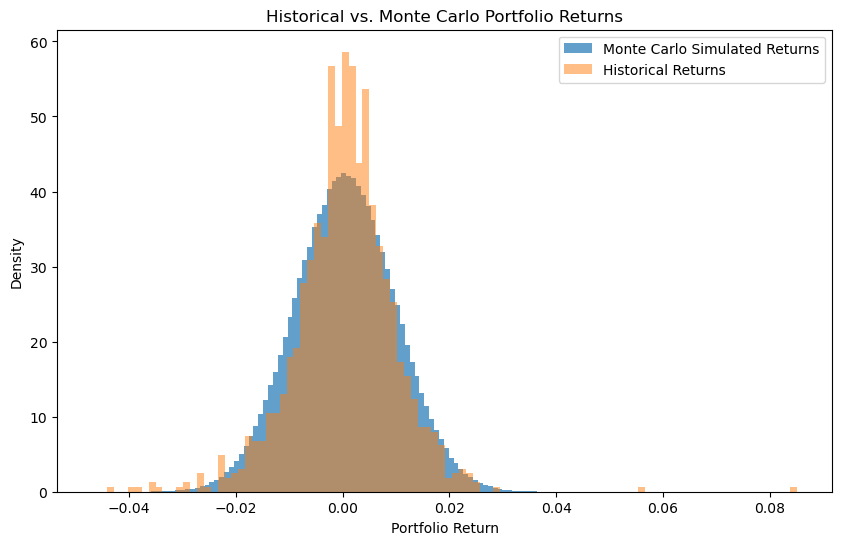

In [29]:
plt.figure(figsize=(10,6))

plt.hist(
    simulated_pf_returns,
    bins=100,
    density=True,
    alpha=0.7,
    label='Monte Carlo Simulated Returns'
)

plt.hist(
    pf_returns,
    bins=100,
    density=True,
    alpha=0.5,
    label='Historical Returns'
)

plt.title('Historical vs. Monte Carlo Portfolio Returns')
plt.xlabel('Portfolio Return')
plt.ylabel('Density')
plt.legend()
plt.show()

## 5. Historical Stress Testing

In [30]:
# The 5 worst return days in the sample
worst_days = pf_returns.nsmallest(5)
print(worst_days)
worst_dates = list(worst_days.index)
worst_days_returns = returns.loc[worst_dates]
print(worst_days_returns)

Date
2025-04-04   -0.044111
2025-04-03   -0.039430
2022-06-13   -0.038857
2022-09-13   -0.035966
2022-05-05   -0.035355
dtype: float64
Ticker           SPY       QQQ       TLT       GLD       IWM
Date                                                        
2025-04-04 -0.058543 -0.062109  0.010887 -0.023392 -0.044608
2025-04-03 -0.049281 -0.053534  0.004594 -0.006038 -0.064196
2022-06-13 -0.037968 -0.046496 -0.031379 -0.026412 -0.046979
2022-09-13 -0.043483 -0.054837  0.002328 -0.013011 -0.039121
2022-05-05 -0.035543 -0.050364 -0.027398 -0.003811 -0.040564


In [31]:
worst_day_date = worst_days.index[0]
hist_stress = returns.loc[worst_day_date]
hist_pf_returns = hist_stress @ weights
hist_stress_loss = -(hist_pf_returns) * pf_value
print(worst_day_date, hist_pf_returns, hist_stress_loss)

2025-04-04 00:00:00 -0.044111419150134085 44111.41915013408


In [32]:
stress_table = []
for day in worst_days.index:
    hist_stress = returns.loc[day]
    hist_pf_returns = hist_stress @ weights
    hist_stress_loss = -(hist_pf_returns) * pf_value
    stress_table.append({"Day": day, "Portfolio Return": hist_pf_returns, "Stress Loss": hist_stress_loss})

stress_table = pd.DataFrame(stress_table)
print(stress_table)

         Day  Portfolio Return   Stress Loss
0 2025-04-04         -0.044111  44111.419150
1 2025-04-03         -0.039430  39430.058655
2 2022-06-13         -0.038857  38857.373354
3 2022-09-13         -0.035966  35966.222403
4 2022-05-05         -0.035355  35355.480319


In [33]:
asset_contribution = {}
for ticker in tickers:
    contribution = returns.loc[worst_day_date, ticker] * weights[tickers.index(ticker)]
    asset_contribution[ticker] = contribution
print(asset_contribution)

{'SPY': np.float64(-0.023417240446784462), 'QQQ': np.float64(-0.015527206172714775), 'TLT': np.float64(0.0016330940084880341), 'GLD': np.float64(-0.002339226273628292), 'IWM': np.float64(-0.004460840265494592)}


In [34]:
loss_contribution = []
for ticker in tickers:
    lc = asset_contribution[ticker] * 100 / pf_returns[worst_day_date]
    loss_contribution.append({ticker: lc})
print(loss_contribution)

[{'SPY': np.float64(53.0865723614183)}, {'QQQ': np.float64(35.19996969462174)}, {'TLT': np.float64(-3.7022023774156216)}, {'GLD': np.float64(5.30299482242158)}, {'IWM': np.float64(10.112665498953987)}]


In [35]:
# April 2022 - June 2022: rate-hiking cycle
stress_2022 = pf_returns.loc['2022-04-01':'2022-06-30']
print(stress_2022)

Date
2022-04-01    0.001713
2022-04-04    0.008180
2022-04-05   -0.016985
2022-04-06   -0.011826
2022-04-07    0.001534
                ...   
2022-06-24    0.022204
2022-06-27   -0.004380
2022-06-28   -0.017134
2022-06-29    0.001153
2022-06-30   -0.006420
Length: 62, dtype: float64


In [36]:
cum_return_2022 = (1 + stress_2022).prod() - 1
PnL_2022 = (cum_return_2022) * pf_value
print(cum_return_2022, PnL_2022)

-0.1620955024060846 -162095.50240608462


In [37]:
worst_day_2022 = stress_2022.min()
worst_loss_2022 = -(worst_day_2022) * pf_value
print(worst_day_2022, worst_loss_2022)

-0.038857373353528145 38857.37335352814


In [38]:
# April 2025
stress_2025 = pf_returns.loc['2025-04-01':'2025-04-30']
print(stress_2025)

Date
2025-04-01    0.004257
2025-04-02    0.006042
2025-04-03   -0.039430
2025-04-04   -0.044111
2025-04-07   -0.007686
2025-04-08   -0.015689
2025-04-09    0.085098
2025-04-10   -0.034055
2025-04-11    0.015926
2025-04-14    0.007252
2025-04-15    0.000336
2025-04-16   -0.013297
2025-04-17   -0.000422
2025-04-21   -0.017242
2025-04-22    0.018976
2025-04-23    0.012410
2025-04-24    0.020493
2025-04-25    0.005729
2025-04-28    0.002865
2025-04-29    0.005045
2025-04-30   -0.002462
dtype: float64


In [39]:
cum_return_2025 = (1 + stress_2025).prod() - 1
PnL_2025 = (cum_return_2025) * pf_value
worst_day_2025 = stress_2025.min()
worst_loss_2025 = -(worst_day_2025) * pf_value
print(cum_return_2025, PnL_2025, worst_day_2025, worst_loss_2025)

0.0031445218237295958 3144.521823729596 -0.04411141915013409 44111.41915013409


In [40]:
stress_comparison = pd.DataFrame({'Stress Period': ['Apr-Jun 2022', 'April 2025'], 
                                  'Cumulative Return': [cum_return_2022, cum_return_2025], 
                                  'Cumulative PnL': [PnL_2022, PnL_2025], 
                                  'Worst Single Day Return': [worst_day_2022, worst_day_2025],
                                  'Worst Single Day Loss': [worst_loss_2022, worst_loss_2025]})
print(stress_comparison)

  Stress Period  Cumulative Return  Cumulative PnL  Worst Single Day Return  \
0  Apr-Jun 2022          -0.162096  -162095.502406                -0.038857   
1    April 2025           0.003145     3144.521824                -0.044111   

   Worst Single Day Loss  
0           38857.373354  
1           44111.419150  


This historical stress period analysis shows how losses can become abnormally large under periods of adverse conditions in the market. From April 
to June 2022, the portfolio experienced losses of ~\\$162,095 even though its worst single day loss was $38,857. This illustrates how prolonged market 
stress periods can cause portfolio losses to far exceed the worst losses of individual days.

In [41]:
asset_stress_2022 = returns.loc['2022-04-01':'2022-06-30']

print(asset_stress_2022)

Ticker           SPY       QQQ       TLT       GLD       IWM
Date                                                        
2022-04-01  0.002834 -0.001903  0.003806 -0.006366  0.011204
2022-04-04  0.008567  0.020588 -0.006949  0.004847  0.001638
2022-04-05 -0.012631 -0.022204 -0.022592 -0.006265 -0.023664
2022-04-06 -0.010000 -0.021712 -0.008094  0.002343 -0.014188
2022-04-07  0.005039  0.002378 -0.007533  0.003785 -0.003248
...              ...       ...       ...       ...       ...
2022-06-24  0.031794  0.034263 -0.013843 -0.000998  0.030972
2022-06-27 -0.003820 -0.007332 -0.008529 -0.001117  0.003712
2022-06-28 -0.020433 -0.030467  0.004660 -0.001648 -0.018778
2022-06-29 -0.000814  0.000917  0.015609 -0.000766 -0.010148
2022-06-30 -0.008124 -0.012403  0.008782 -0.006077 -0.007792

[62 rows x 5 columns]


In [42]:
asset_cum_returns_2022 = (1 + asset_stress_2022).prod() - 1
print(asset_cum_returns_2022)

Ticker
SPY   -0.161103
QQQ   -0.225413
TLT   -0.125933
GLD   -0.067478
IWM   -0.172766
dtype: float64


In [43]:
asset_wealth_2022 = (1 + asset_stress_2022).cumprod()
asset_drawdown_2022 = asset_wealth_2022 / asset_wealth_2022.cummax() - 1
max_asset_drawdown_2022 = asset_drawdown_2022.min()
print(max_asset_drawdown_2022)

Ticker
SPY   -0.197351
QQQ   -0.265123
TLT   -0.175184
GLD   -0.087679
IWM   -0.209601
dtype: float64


In [44]:
cum_asset_contribution_2022 = asset_cum_returns_2022 * weights
print(cum_asset_contribution_2022)

Ticker
SPY   -0.064441
QQQ   -0.056353
TLT   -0.018890
GLD   -0.006748
IWM   -0.017277
dtype: float64


In [45]:
pf_wealth_2022 = (1 + stress_2022).cumprod()
drawdown_2022 = pf_wealth_2022 / pf_wealth_2022.cummax() - 1
pf_max_drawdown_2022 = drawdown_2022.min()
drawdown_comparison = asset_drawdown_2022.min() - pf_max_drawdown_2022
print("Portfolio max drawdown (Apr-Jun 2022):", pf_max_drawdown_2022)
print(drawdown_comparison)

Portfolio max drawdown (Apr-Jun 2022): -0.19251979152912646
Ticker
SPY   -0.004831
QQQ   -0.072603
TLT    0.017336
GLD    0.104840
IWM   -0.017081
dtype: float64


## 6. Risk Decomposition

In [46]:
# Risk Contribution = asset's share of portfolio volatility, calculated using Euler decomposition.
daily_pf_vol = returns.dot(weights).std()
cov_with_pf = cov_matrix @ weights
risk_contribution = cov_with_pf * weights  / daily_pf_vol
pct_risk_contribution = risk_contribution / daily_pf_vol
print(risk_contribution, (pct_risk_contribution * 100).round(2))

Ticker
SPY    0.004168
QQQ    0.003396
TLT    0.000385
GLD    0.000260
IWM    0.001220
dtype: float64 Ticker
SPY    44.20
QQQ    36.02
TLT     4.09
GLD     2.75
IWM    12.94
dtype: float64


In [47]:
print("Daily portfolio volatility:", daily_pf_vol)
print("Sum of risk contributions:", risk_contribution.sum())
print("Sum of risk contribution percentages:", pct_risk_contribution.sum())

Daily portfolio volatility: 0.009429722474047832
Sum of risk contributions: 0.009429722474047837
Sum of risk contribution percentages: 1.0000000000000007


In [48]:
mcr = risk_contribution / weights
print(mcr)

Ticker
SPY    0.010421
QQQ    0.013585
TLT    0.002568
GLD    0.002596
IWM    0.012203
dtype: float64


In [49]:
# Difference cross check on the MCR above:
qqq_shift_weights = weights.copy()
qqq_shift_weights[1] += 0.0001
qqq_shift_weights[0] -= 0.0001
qqq_shift_weights.sum()
qqq_shift_variance = qqq_shift_weights.T @ cov_matrix @ qqq_shift_weights
qqq_shift_vol = np.sqrt(qqq_shift_variance) * np.sqrt(252)
qqq_vol_change = qqq_shift_vol - pf_vol
print(qqq_vol_change)

5.0243147241280095e-06


In [50]:
# Same check, but other way around (SPY: +0.01%, QQQ: -0.01%).
spy_shift_weights = weights.copy()
spy_shift_weights[0] += 0.0001
spy_shift_weights[1] -= 0.0001
spy_shift_variance = spy_shift_weights.T @ cov_matrix @ spy_shift_weights
spy_shift_vol = np.sqrt(spy_shift_variance) * np.sqrt(252)
spy_vol_change = spy_shift_vol - pf_vol
print(spy_vol_change)

-5.02399914228957e-06


In [51]:
risk_budget = pd.DataFrame({'Capital Weight': weights, 'Risk Contribution %': pct_risk_contribution})
risk_budget['Difference'] = (risk_budget['Risk Contribution %'] - risk_budget['Capital Weight'])
risk_budget['Risk/Capital Ratio'] = (risk_budget['Risk Contribution %'] / risk_budget['Capital Weight'])
risk_budget

,Capital Weight,Risk Contribution %,Difference,Risk/Capital Ratio
Ticker,,,,
SPY,0.40,0.442029,0.042029,1.105073
QQQ,0.25,0.360176,0.110176,1.440706
TLT,0.15,0.040856,-0.109144,0.272374
GLD,0.10,0.027526,-0.072474,0.275258
IWM,0.10,0.129412,0.029412,1.294122


In [52]:
# Herfindahl-Hirschman Index (HHI):
# 1/HHI = effective number of independent risk positions.
risk_hhi = np.sum(pct_risk_contribution ** 2)
eff_risk_pos = 1/risk_hhi
eff_risk_pos

np.float64(2.9045155369256777)

## 7. Scenario-Based Stress Tests

In [53]:
eq_selloff = np.array([-0.10, -0.15, 0, 0, -0.15]) #equity selloff
scenario_return = weights @ eq_selloff
scenario_PnL = scenario_return * pf_value
print(f'equity selloff PnL: {scenario_PnL}')
eq_bond_selloff = np.array([-0.10, -0.15, -0.08, 0, -0.15])
scenario_return_2 = weights @ eq_bond_selloff
scenario_PnL_2 = scenario_return_2 * pf_value
print(f'equity & bond selloff PnL: {scenario_PnL_2}')
cross_selloff = np.array([-0.15, -0.20, -0.08, 0.05, -0.20])
scenario_return_3 = weights @ cross_selloff
scenario_PnL_3 = scenario_return_3 * pf_value
print(f'cross asset selloff + gold pnl: {scenario_PnL_3}')
con_stress = np.array([-0.20, -0.25, 0, 0, -0.25]) # concentration stress
scenario_return_4 = weights @ con_stress
scenario_PnL_4 = scenario_return_4 * pf_value
print(f'concentration stress scenario PnL: {scenario_PnL_4}')

equity selloff PnL: -92500.0
equity & bond selloff PnL: -104500.00000000001
cross asset selloff + gold pnl: -137000.0
concentration stress scenario PnL: -167500.0


In [54]:
scenario_summary = pd.DataFrame({
    "Scenario": [
        "Equity Selloff",
        "Equity + Bond Selloff",
        "Cross-Asset Selloff + Gold",
        "Concentration Stress"
    ],
    "Portfolio Return": [
        scenario_return,
        scenario_return_2,
        scenario_return_3,
        scenario_return_4
    ],
    "P&L": [
        scenario_PnL,
        scenario_PnL_2,
        scenario_PnL_3,
        scenario_PnL_4
    ]
})

scenario_summary

,Scenario,Portfolio Return,P&L
0,Equity Selloff,-0.0925,-92500.0
1,Equity + Bond Selloff,-0.1045,-104500.0
2,Cross-Asset Selloff + Gold,-0.1370,-137000.0
3,Concentration Stress,-0.1675,-167500.0


## 8. Final Risk Dashboard

This dashboard consolidates the primary portfolio risk metrics calculated over the course of this project, summarizing the following:
    
Value at Risk (VaR)
Expected Shortfall (ES)
Calibration Check
Risk Contribution and Risk Concentration
Marginal Contribution to Risk (MCR)
Stress-testing Results

VaR Comparison
   Confidence  Historical VaR  Parametric VaR  Parametric - Historical VaR  \
0        0.90    10269.084620    11618.281598                  1349.196978   
1        0.95    14887.246181    15044.119212                   156.873030   
2        0.99    25893.462120    21470.420830                 -4423.041290   

   Parametric - Historical VaR Percentage Difference  Expected Shortfall  \
0                                           0.131384        16914.238650   
1                                           0.010537        21442.062584   
2                                          -0.170817        32546.533649   

   Monte Carlo VaR  
0     11413.097911  
1     15149.938369  
2     20644.214895  
VaR vs. Expected Shortfall
  Confidence Level           VaR            ES   Difference  \
0              90%  10269.084620  16914.238650  6645.154030   
1              95%  14887.246181  21442.062584  6554.816403   
2              99%  25893.462120  32546.533649  6653.071529   

   

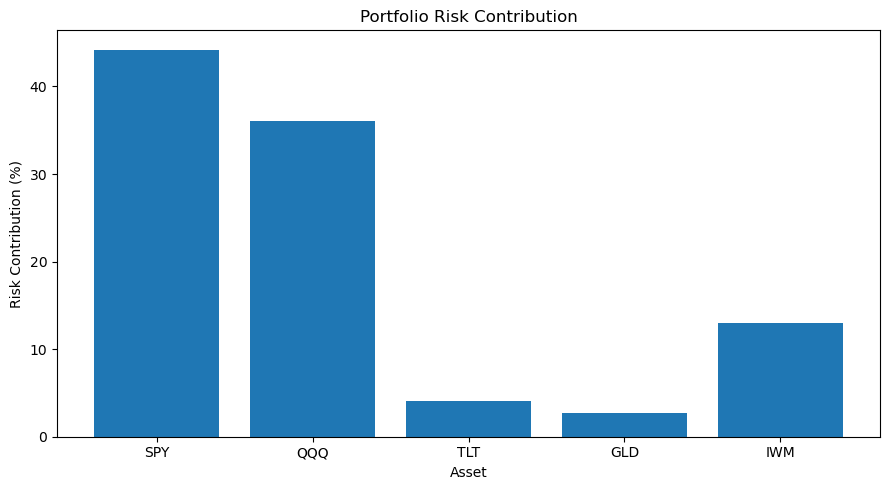

Marginal Contribution to Risk (MCR)
  Asset       MCR
0   SPY  0.010421
1   QQQ  0.013585
2   TLT  0.002568
3   GLD  0.002596
4   IWM  0.012203
Stress Testing
                     Scenario  Portfolio Return       P&L
0              Equity Selloff           -0.0925  -92500.0
1       Equity + Bond Selloff           -0.1045 -104500.0
2  Cross-Asset Selloff + Gold           -0.1370 -137000.0
3        Concentration Stress           -0.1675 -167500.0


In [55]:
#Risk Dashboard

# 1. VaR Comparison 


dashboard_var = var_engine(pf_returns, confidence_levels, pf_value)
dashboard_var['Monte Carlo VaR'] = [mc_var(returns.mean(), cov_matrix, weights, cl, pf_value, 10000) for cl in dashboard_var['Confidence']]

print("VaR Comparison")
print(dashboard_var)

# 2. VaR vs. Expected Shortfall

print("VaR vs. Expected Shortfall")
dashboard_es = es_vs_var.copy()
print(dashboard_es)


# 3. Calibration Check

calibration_check_results = calibration_check(pf_returns, [0.95])
print(calibration_check_results)
print(f"Conditional Coverage LR Statistic: {lr_cc:.4f}")
print(f"Conditional Coverage p-value: {p_value_cc:.4f}")

# 4. Risk Contribution


print("Portfolio Risk Contribution")
print(risk_budget)

print(f"Effective Number of Risk Positions: "f"{eff_risk_pos:.2f}")


# 5. Portfolio Risk Contribution by Asset


plt.figure(figsize=(9, 5))
plt.bar(pct_risk_contribution.index,pct_risk_contribution * 100)
plt.title("Portfolio Risk Contribution")
plt.xlabel("Asset")
plt.ylabel("Risk Contribution (%)")
plt.tight_layout()
plt.show()


# 6. Marginal Contribution to Risk


print("Marginal Contribution to Risk (MCR)")
dashboard_mcr = pd.DataFrame({"Asset": mcr.index,"MCR": mcr.values})
print(dashboard_mcr)


# 7. Stress Testing


print("Stress Testing")
print(scenario_summary)

In [56]:
calibration_check_results = calibration_check(pf_returns, confidence_levels)
print(calibration_check_results)

   Confidence Level  VaR Threshold  Breaches  Breach Rate  \
0              0.90      -0.010269       126     0.100478   
1              0.95      -0.014887        63     0.050239   
2              0.99      -0.025893        13     0.010367   

   Expected Breach Rate  Rate Difference  
0                  0.10        -0.000478  
1                  0.05        -0.000239  
2                  0.01        -0.000367  


Model Limitations and Risk Interpretation

Limitations:

This risk framework combines several measures of portfolio risk, with each having their own individual limitations.

1. Historical Dependence
Risk metrics like Historical VaR and Expected Shortfall rely on historical data to estimate future portfolio returns. However, the historical sample may not contain enough extreme market scenario observations to represent future tail events. Thus, these metrics may underestimate portfolio risk under market conditions different from the historical samples used to calculate them.

2. Parametric Distribution Assumptions
Parametric VaR assumes that portfolio returns are normally distributed, which may not accurately portray actual returns, particularly at the tails.
At a 99% confidence level, historical VaR (\\$25,893) exceeded parametric VaR (\\$21,470), indicating that the parametric approach to VaR may understate
the severity of the portfolio's tail behavior.

3. VaR Tail Blindness
Although VaR allows us to obtain a useful loss threshold at a given confidence level, it does not describe the severity of losses beyond said threshold. Thus, VaR is insufficient as a sole measure of tail risk. Expected Shortfall (ES) describes the average loss beyond the VaR threshold, allowing us to more accurately assess the severity of tail losses. 

4. Asset Dependence Changes under Stress Scenarios
The correlations between individual assets and covariance matrices were calculated using historical data, which may not accurately apply during extreme market scenarios, as dependences between assets can change drastically under changing market conditions. Therefore, risk estimates that applied before such a shock may not entirely capture these changes under extreme market conditions.

5. Stress Scenario Hypotheticality
The stress scenarios used in this project were designed to evaluate the sensitivity of the portfolio to extreme market events, and to assess the 
magnitude of losses from various asset shocks. Therefore, they should be interpreted as measures of the portfolio's vulnerability and not as forecasts.



Risk Interpretation

Analyzing the results indicates that the portfolio is considerably risk concentrated, with equities representing 75% of portfolio weight but over
93% of portfolio risk. Furthermore, risk decomposition showed us that QQQ had both the highest marginal contribution to risk (MCR) and highest 
risk-to-capital ratio, with QQQ being responsible for 36% of the risk contribution despite only making up 25% of portfolio capital. Based on these 
results, we can conclude that a marginal increase in QQQ's portfolio weight would increase portfolio risk more than an equivalent marginal increase in any other asset, all else held equal. The portfolio's effective number of risk positions is ~2.90 despite containing five assets, suggesting that the portfolio is considerably less diversified than one might expect from a portoflio with five assets. This can be largely attributed to the portfolio's large equity exposure and the high risk contributions of QQQ and IWM given their weights.

Looking at our 95% historical VaR (\\$14,887) and Expected Shortfall (\\$21,442) results, we see a considerable difference between the two ($6,555), 
indicating that the losses within this 5% tail can be substantially larger than our VaR threshold. The stress scenarios reinforce this conclusion as 
well, with modeled portfolio losses ranging from \\$92,500 to \\$167,500 over the four scenarios, and the largest lossess occurring in scenarios involving substantial declines in the portfolio's equity positions, as is consistent with the risk contribution results.

Overall, the analysis shows that the portfolio's risk is largely driven by equity concentration, the volatility of individual assets, and the covariance and correlation between individual assets